In [ ]:
import ase.io
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ASE optimization tools
from ase.filters import ExpCellFilter, FrechetCellFilter
from ase.optimize import LBFGS
from ase.calculators.mixing import SumCalculator
from ase.units import Bohr

# MACE
from mace.calculators import mace_mp        # if using MACE-MP
from mace.calculators.mace import MACECalculator   # local models

# Torch-DFTD3
from torch_dftd.torch_dftd3_calculator import TorchDFTD3Calculator

from ase.build import make_supercell


# ===========================================================
# 1. Load all water structures
# ===========================================================
ats = ase.io.read("../chho_data/water_phases/all_water_phases.xyz", ":")

relaxed_structs = []
relaxed_energies = []

# ===========================================================
# 2. Loop through frames and relax each one with MACE + D3
# ===========================================================
mace_model_path = "/home/jerry528/foundation_models/mace-omat-0-small.model"   # <--- change this

mace_calc = MACECalculator(
    model_path=mace_model_path,
    device="cuda",
    energies=True,
    forces=True,
    stresses=True,
    enable_cueq=True
)

n_supercell = 2
P = np.diag([n_supercell, n_supercell, n_supercell])   # 2×2×2 supercell
bohr_per_ang = 1.88972612546

# ===========================================================
# 2. Loop over D3 cutoffs
# ===========================================================
for cutoff_A in [8, 10, 12, 16, 20, 50]:
    cutoff_bohr = float(cutoff_A * bohr_per_ang) # check
    print(f"\n======================")
    print(f"  D3 cutoff = {cutoff_bohr} Bohr")
    print(f"======================")

    relaxed_structs = []
    relaxed_energies = []

    # -------------------------------------------------------
    # Build D3 calculator ONCE per cutoff
    # -------------------------------------------------------
    d3_calc = TorchDFTD3Calculator(
        atoms=None,
        damping="bj",
        cutoff=cutoff_bohr * Bohr,
        device="cuda",
    )

    # -------------------------------------------------------
    # Use SumCalculator with the fixed MACE + this cutoff D3
    # -------------------------------------------------------
    combined_calc = SumCalculator([mace_calc, d3_calc])

    # -------------------------------------------------------
    # Relax all structures for this cutoff
    # -------------------------------------------------------
    for i, at0 in enumerate(ats):

        at = at0.copy()
        at.pbc = True
        at = make_supercell(at, P)
        at.set_calculator(combined_calc)

        # --- Flexible cell relaxation ---
        ucf = ExpCellFilter(at, hydrostatic_strain=True)


        opt = LBFGS(
            ucf,
        #    logfile=f"../results/water_phases/lbfgs_log/relax_mace_d3_cut{cutoff_A}_{i}.log",
        )
        opt.run(fmax=1e-3)

        # Energy
        E = at.get_potential_energy()
        relaxed_energies.append(E)
        relaxed_structs.append(at)

        print(f"[cut {cutoff_bohr} | frame {i:4d}]  E = {E:.6f} eV")

    # -------------------------------------------------------
    # Save results for this cutoff
    # -------------------------------------------------------
    np.savetxt(
        f"../results/water_phases/relaxed_energies/relaxed_MACE_D3_cut{cutoff_A}_energies_{n_supercell}.txt",
        np.column_stack([np.arange(len(relaxed_energies)), relaxed_energies]),
        header="index   relaxed_energy_eV",
    )

/home/jerry528/miniconda3/envs/fastd32/lib/python3.12/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/home/jerry528/miniconda3/envs/fastd32/lib/python3.12/site-packages/mace/modules/models.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "atomic_numbers", torch.tensor(atomic_numbers, dtype=torch.int64)



  D3 cutoff = 94.486306273 Bohr


/tmp/ipykernel_4013709/1348362331.py:83: FutureWarning: Please use atoms.calc = calc
  at.set_calculator(combined_calc)
/tmp/ipykernel_4013709/1348362331.py:86: DeprecationWarning: Use FrechetCellFilter for better convergence w.r.t. cell variables.
  ucf = ExpCellFilter(at, hydrostatic_strain=True)  # <- key change


[cut 94.486306273 | frame    0]  E = -477.087318 eV
[cut 94.486306273 | frame    1]  E = -477.131940 eV
[cut 94.486306273 | frame    2]  E = -1431.000810 eV
[cut 94.486306273 | frame    3]  E = -1425.395129 eV
[cut 94.486306273 | frame    4]  E = -1427.026008 eV
[cut 94.486306273 | frame    5]  E = -1423.043079 eV
[cut 94.486306273 | frame    6]  E = -1423.066045 eV
[cut 94.486306273 | frame    7]  E = -1423.125282 eV
[cut 94.486306273 | frame    8]  E = -471.833332 eV
[cut 94.486306273 | frame    9]  E = -235.306827 eV
[cut 94.486306273 | frame   10]  E = -472.965867 eV
[cut 94.486306273 | frame   11]  E = -476.629087 eV
[cut 94.486306273 | frame   12]  E = -476.656631 eV
[cut 94.486306273 | frame   13]  E = -1418.377843 eV
[cut 94.486306273 | frame   14]  E = -473.828514 eV
[cut 94.486306273 | frame   15]  E = -1351.475848 eV
[cut 94.486306273 | frame   16]  E = -1600.366979 eV
[cut 94.486306273 | frame   17]  E = -807.045770 eV


In [ ]:
mp_labels

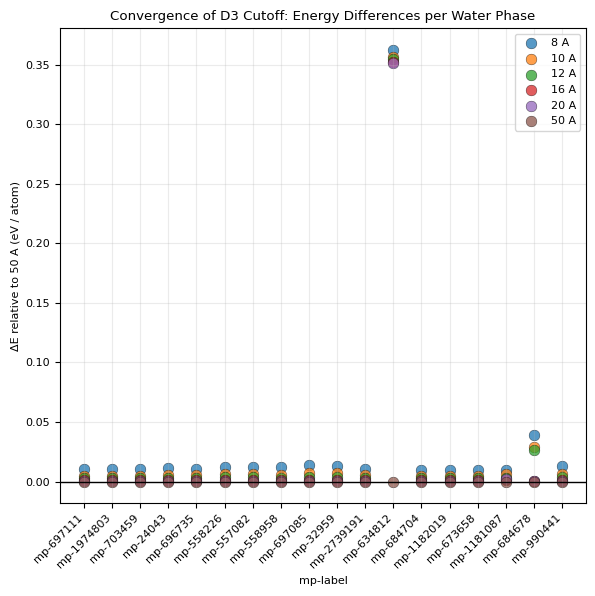

Done. Plots saved:


In [27]:
# ===========================================================
# Load original mp-labels
# ===========================================================
mp_labels = [at.info.get("material_id", f"frame_{i}") for i, at in enumerate(ats)]
scaling = [len(at) for at in ats]
n_supercell = 2

unique_labels = list(dict.fromkeys(mp_labels))
label_to_x = {lab: i for i, lab in enumerate(unique_labels)}
x = np.array([label_to_x[l] for l in mp_labels])

# ===========================================================
# Load energies from each cutoff
# ===========================================================
cutoffs = [8, 10, 12, 16, 20, 50]
all_energies = {}

for c in cutoffs:
    fname = f"../results/water_phases/relaxed_energies/relaxed_MACE_D3_cut{c}_energies_{n_supercell}.txt"
    arr = np.loadtxt(fname)
    all_energies[c] = arr[:, 1]

plt.figure(figsize=(6, 6))

ref50 = all_energies[50]

for c in cutoffs:
    dE = (all_energies[c] - ref50) / np.array(scaling)
    
    plt.scatter(
        x, dE,
        s=60, alpha=0.75,
        label=f"{c} A",
        edgecolor="black",
        linewidth=0.3,
    )

plt.axhline(0, color="black", lw=1)
plt.xticks(
    ticks=range(len(unique_labels)),
    labels=mp_labels,
    rotation=45,
    ha="right",
)
plt.ylabel("ΔE relative to 50 A (eV / atom)")
plt.xlabel("mp-label")
plt.title("Convergence of D3 Cutoff: Energy Differences per Water Phase")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.savefig("plot_mace_d3_cutoff_scan_delta.png", dpi=200)
plt.show()

print("Done. Plots saved:")